In [ ]:
# 각종 시행착오를 거쳐 0.3.0으로 거듭남.

In [1]:
import sys
from utils.Mediapipe import MediaPipe
sys.path.append('/home/hocheol/inskin_ai/EfficientNet/src/preprocess/wrinkle/v0.3/v0.3.0')
from wrinkle_preprocess import wrinkle_preprocess
sys.path.append('/home/hocheol/inskin_ai/EfficientNet/src/preprocess')
from remove_non_skin import remove_non_skin
# 데이터 추가(045)
# 주름은 피부 아닌 부분 마스킹 후 주름 부위 crop. 배경까지
# mp_image 사용

face_landmarker = MediaPipe()

IMAGE_PATH = '/home/hocheol/inskin_ai/no_track/datasets/origin_data-simple/034_data/0000/0000_CRS_19_01.jpg'

with open(IMAGE_PATH, 'rb') as f:
    byte_image = f.read()
    mp_image = face_landmarker.create_mp_image(byte_image)

np_image = mp_image.numpy_view()

detection_results = face_landmarker.landmarker.detect(mp_image)
landmarks = detection_results.face_landmarks[0]

forehead, rt_eye, lf_eye, nasolabial, oral, rt_cheek, lt_cheek = wrinkle_preprocess(np_image, landmarks)
masked_image = remove_non_skin(np_image, landmarks)

2026-02-19 03:45:48.232824: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-19 03:45:48.232901: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-19 03:45:48.234152: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-19 03:45:48.241247: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1771472750.375742   82511 task_runner.cc:

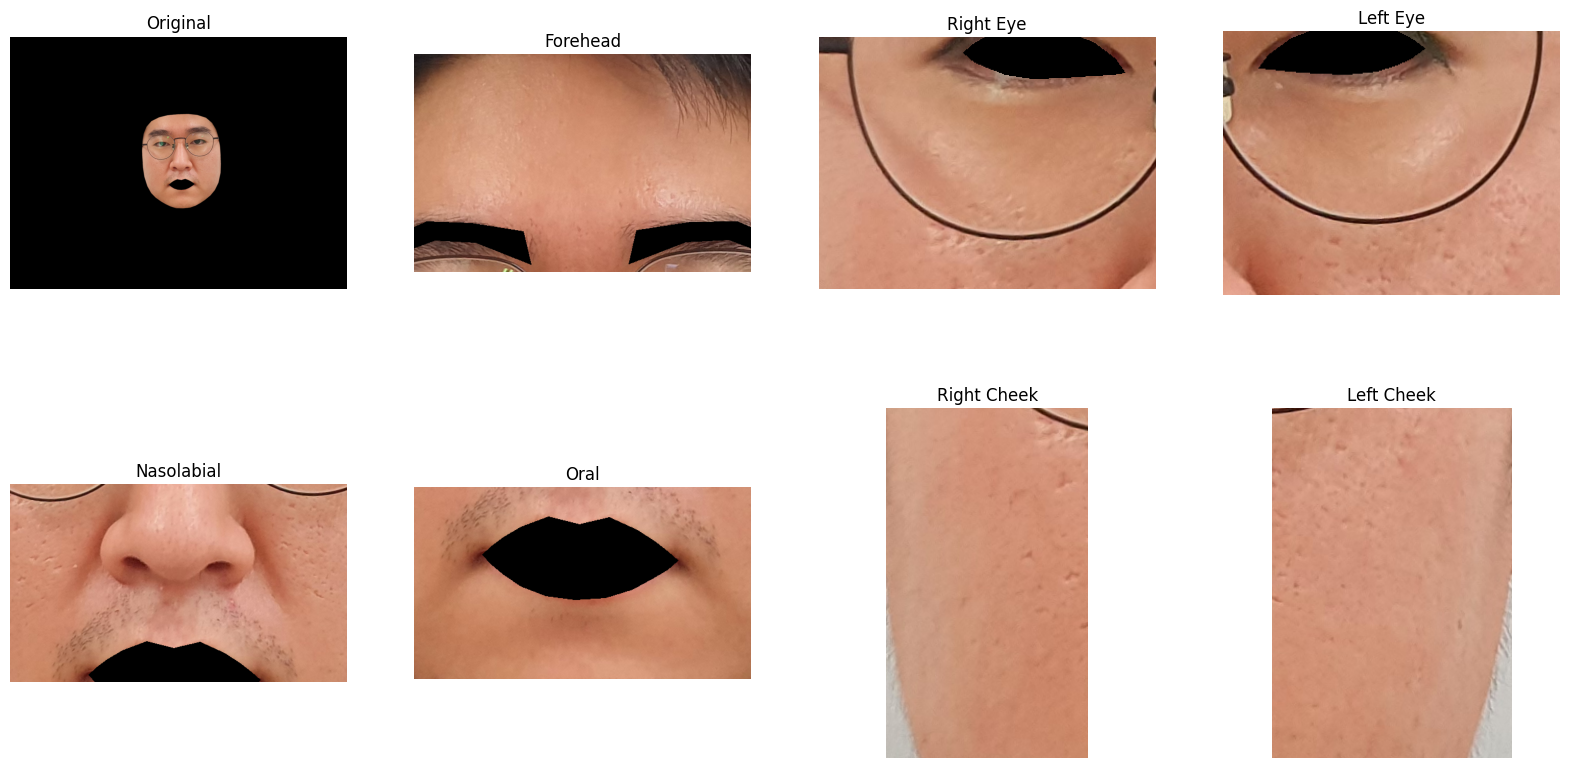

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, figsize=(20, 10))

np_image = mp_image.numpy_view()
for i, img in enumerate([masked_image, forehead, rt_eye, lf_eye, nasolabial, oral, rt_cheek, lt_cheek]):
    r = i // 4
    c = i % 4
    ax[r][c].imshow(img)
    ax[r][c].axis('off')
    ax[r][c].set_title(['Original', 'Forehead', 'Right Eye', 'Left Eye', 'Nasolabial', 'Oral', 'Right Cheek', 'Left Cheek'][i])

plt.show()

In [2]:
from utils.constants import SECTORS
import pandas as pd
wrinkle_root = '/home/hocheol/inskin_ai/no_track/datasets/wrinkle_data/v0.3/v0.3_data/030_data/data'
data_df = pd.read_csv('/home/hocheol/inskin_ai/no_track/datasets/wrinkle_data/labels/wrinkle-260219_034.csv').iloc[:, :-1]

# row[1:].isna().all()에 해당하지 않는 row만 남기기
filtered_df = data_df[~data_df.iloc[:, 1:].isna().all(axis=1)].reset_index(drop=True)

filtered_df

,filename,forehead,right_eye,left_eye,nasolabial,periroal,right_vol,left_vol
0,0000_CRS_19_01.jpg,0.0,0.0,0.0,2.0,1.0,0.0,1.0
1,0000_CRS_46_01.jpg,0.0,0.0,0.0,2.0,1.0,0.0,1.0
2,0001_CRS_19_01.jpg,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,0001_CRS_46_01.jpg,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,0002_CRS_19_01.jpg,NaN,1.0,1.0,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...
3793,1998_CRS_46_01.jpg,4.0,2.0,2.0,4.0,4.0,1.0,1.0
3794,1999_CRS_19_01.jpg,3.0,2.0,1.0,2.0,1.0,0.0,0.0
3795,1999_CRS_46_01.jpg,3.0,2.0,2.0,2.0,1.0,0.0,0.0
3796,2000_CRS_19_01.jpg,NaN,2.0,2.0,1.0,1.0,0.0,0.0


In [ ]:
# 데이터 전처리
import json
import os
from utils.constants import SECTORS

TARGET_ROOT = '/home/hocheol/inskin_ai/no_track/datasets/wrinkle_data/v0.3/v0.3_data'
SOURCE_ROOT = '/home/hocheol/inskin_ai/no_track/datasets/origin_data-simple'

origin_dirs_path = '/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.3/v0.3.0/wrinkle_label_paths.json'

source_paths = set()

with open(origin_dirs_path, 'r') as f:
    origin_dirs = json.load(f)

for origin_dir in origin_dirs:
    print(origin_dir)
    for step in ['train', 'val', 'test']:
        origin_path = os.path.join(origin_dir, f"wrinkle_{step}.json")
        with open(origin_path, 'r') as f:
            json_data = json.load(f)
        
        for data in json_data:
            # print(data)
            
            for sec in SECTORS:
                if data[sec] != -1:
                    source_path = data[f"{sec}_path"].replace(f"{sec}_", '')

                    # .jpg.jpg -> .jpg
                    ext = source_path.split('.')[-1]
                    source_path = source_path.split('.')[0] + f".{ext}"

                    if not os.path.exists(os.path.join(SOURCE_ROOT, source_path)):
                        if os.path.exists(os.path.join(SOURCE_ROOT, source_path.replace('.jpg', '.JPG'))):
                            source_path = source_path.replace('.jpg', '.JPG')
                        else:
                            print(f"File not found: {source_path}")
                            continue
                    
                    # print(target_path)
                    # print(source_path)
                    source_paths.add(source_path)

source_paths = sorted(list(source_paths))
len(source_paths)

2025-10-07 15:27:09.219707: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 15:27:09.273709: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-07 15:27:09.273748: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-07 15:27:09.275547: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-07 15:27:09.283958: I tensorflow/core/platform/cpu_feature_guar

/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.3/v0.3.0/030_data/label
/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.3/v0.3.0/028_data/label
/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.3/v0.3.0/045_data/label


6279

In [ ]:
import sys
from multiprocessing import get_context
from utils.slack import send_slack_message
from tqdm import tqdm
import os

sys.path.append('/home/work/hocheol_dir/workspace/_dataset/preprocess/wrinkle/v0.3/v0.3.0')
from worker import process_wrinkle_image, initializer

NUM_CORES = 4

try:
    with get_context("spawn").Pool(processes=NUM_CORES, initializer=initializer) as pool:
        results = list(tqdm(pool.imap_unordered(process_wrinkle_image, source_paths), total=len(source_paths)))
    
    success_count = sum(1 for r in results if r.startswith("success"))
    fail_count = sum(1 for r in results if r.startswith("failed"))
    skipped_count = sum(1 for r in results if r.startswith("skipped"))

    fail_list = [r for r in results if r.startswith('failed')]

    send_slack_message(f"Wrinkle preprocessing completed. Success: {success_count}, Fail: {fail_count}, Skipped: {skipped_count}")
    for fail_item in fail_list:
        print(fail_item)
except Exception as e:
    print(e)
    send_slack_message(e)
    raise e

  0%|                                                                                                                                  | 0/6279 [00:00<?, ?it/s]2025-10-07 15:28:21.165967: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-07 15:28:21.166019: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-07 15:28:21.166029: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-07 15:28:21.166032: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been register

In [ ]:
import sys
sys.path.append('/home/work/hocheol_dir/workspace/_dataset')
from utils.Mediapipe import MediaPipe

face_landmarker = MediaPipe()

path = os.path.join('/home/work/hocheol_dir/workspace/_dataset/datasets/_origin_data', source_paths[0])
with open(path, 'rb') as f:
    byte_image = f.read()
    mp_image = face_landmarker.create_mp_image(byte_image)

I0000 00:00:1759817958.129889 1605635 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL
W0000 00:00:1759817958.130595 1605635 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1759817958.139072 1607110 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1759817958.162605 1607113 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [20]:
import json
import os

with open('/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.3/v0.3.0/wrinkle_label_paths.json', 'r') as f:
    label_dirs = json.load(f)


for label_dir in label_dirs:
    for step in ['train', 'val', 'test']:
        label_path = os.path.join(label_dir, f"wrinkle_{step}.json")
        with open(label_path, 'r') as f:
            json_data = json.load(f)
        
        for data in json_data:
            for sec in SECTORS:
                if data[sec] == -1:
                    data[f"{sec}_path"] = ''
        
        
        new_label_path = label_path.replace('v0.3.0', 'v0.3.1')
        os.makedirs(os.path.dirname(new_label_path), exist_ok=True)
        with open(new_label_path, 'w') as f:
            json.dump(json_data, f, indent=2, ensure_ascii=False)

In [34]:
from utils.constants import SECTORS

img_root = '/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.3/v0.3_data'
fail_list = []

with open('/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.3/v0.3.1/wrinkle_label_paths.json', 'r') as f:
    label_dirs = json.load(f)

for label_dir in label_dirs:
    for step in ['train', 'val', 'test']:
        json_path = os.path.join(label_dir, f"wrinkle_{step}.json")
        with open(json_path, 'r') as f:
            json_data = json.load(f)

        for data in json_data:
            for sec in SECTORS:
                image_path = data[f"{sec}_path"]
                if image_path != '':
                    if not os.path.exists(os.path.join(img_root, image_path)):
                        if os.path.exists(os.path.join(img_root, image_path.replace('.jpg', '.JPG'))):
                            data[f"{sec}_path"] = image_path.replace('.jpg', '.JPG')
                        elif os.path.exists(os.path.join(img_root, image_path.replace('.jpg.jpg', '.jpg'))):
                            data[f"{sec}_path"] = image_path.replace('.jpg.jpg', '.jpg')
                        
                        else:
                            fail_list.append((image_path, data[sec]))

        os.makedirs(os.path.dirname(json_path.replace('v0.3.1', 'v0.3.2')), exist_ok=True)
        with open(json_path.replace('v0.3.1', 'v0.3.2'), 'w') as f:
            json.dump(json_data, f, indent=2, ensure_ascii=False)
    
len(fail_list)

0

In [36]:
img_root = '/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.3/v0.3_data'
label_paths = '/home/work/hocheol_dir/workspace/_dataset/datasets/wrinkle_data/v0.3/v0.3.2/wrinkle_label_paths.json'

with open(label_paths, 'r') as f:
    label_dirs = json.load(f)
    
for label_dir in label_dirs:
    for step in ['train', 'val', 'test']:
        json_path = os.path.join(label_dir, f"wrinkle_{step}.json")
        with open(json_path, 'r') as f:
            json_data.extend(json.load(f))

for data in json_data:
    for sec in SECTORS:
        image_path = data[f"{sec}_path"]
        if image_path != '':
            if not os.path.exists(os.path.join(img_root, image_path)):
                print(f"File not found: {image_path}, label: {data[sec]}")

len(json_data)

6444